# Neural Network Implementation

## Import the necessary libraries to implement Neural network

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at te

## 1. Load your data set, perform EDA and generate independent and dependent variables

In [3]:
df = pd.read_csv('fuel.csv')
df.head()

,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,9.2,6.7,8.1,35,186
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,8.5,6.5,7.6,37,175
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,12.2,7.4,10.0,28,230
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,13.4,9.2,11.5,25,264
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,10.0,7.0,8.6,33,198


In [4]:
df.shape

(22556, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22556 entries, 0 to 22555
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              22556 non-null  int64  
 1   MAKE              22556 non-null  object 
 2   MODEL             22556 non-null  object 
 3   VEHICLE CLASS     22556 non-null  object 
 4   ENGINE SIZE       22556 non-null  float64
 5   CYLINDERS         22556 non-null  int64  
 6   TRANSMISSION      22556 non-null  object 
 7   FUEL              22556 non-null  object 
 8   FUEL CONSUMPTION  22556 non-null  float64
 9   HWY (L/100 km)    22556 non-null  float64
 10  COMB (L/100 km)   22556 non-null  float64
 11  COMB (mpg)        22556 non-null  int64  
 12  EMISSIONS         22556 non-null  int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 2.2+ MB


In [6]:
df.isnull().sum()

YEAR                0
MAKE                0
MODEL               0
VEHICLE CLASS       0
ENGINE SIZE         0
CYLINDERS           0
TRANSMISSION        0
FUEL                0
FUEL CONSUMPTION    0
HWY (L/100 km)      0
COMB (L/100 km)     0
COMB (mpg)          0
EMISSIONS           0
dtype: int64

In [7]:
df.describe()

,YEAR,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
count,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000,22556.000000
mean,2011.554442,3.356646,5.854141,12.763513,8.919126,11.034341,27.374534,250.068452
std,6.298269,1.335425,1.819597,3.500999,2.274764,2.910920,7.376982,59.355276
min,2000.000000,0.800000,2.000000,3.500000,3.200000,3.600000,11.000000,83.000000
25%,2006.000000,2.300000,4.000000,10.400000,7.300000,9.100000,22.000000,209.000000
50%,2012.000000,3.000000,6.000000,12.300000,8.400000,10.600000,27.000000,243.000000
75%,2017.000000,4.200000,8.000000,14.725000,10.200000,12.700000,31.000000,288.000000
max,2022.000000,8.400000,16.000000,30.600000,20.900000,26.100000,78.000000,608.000000


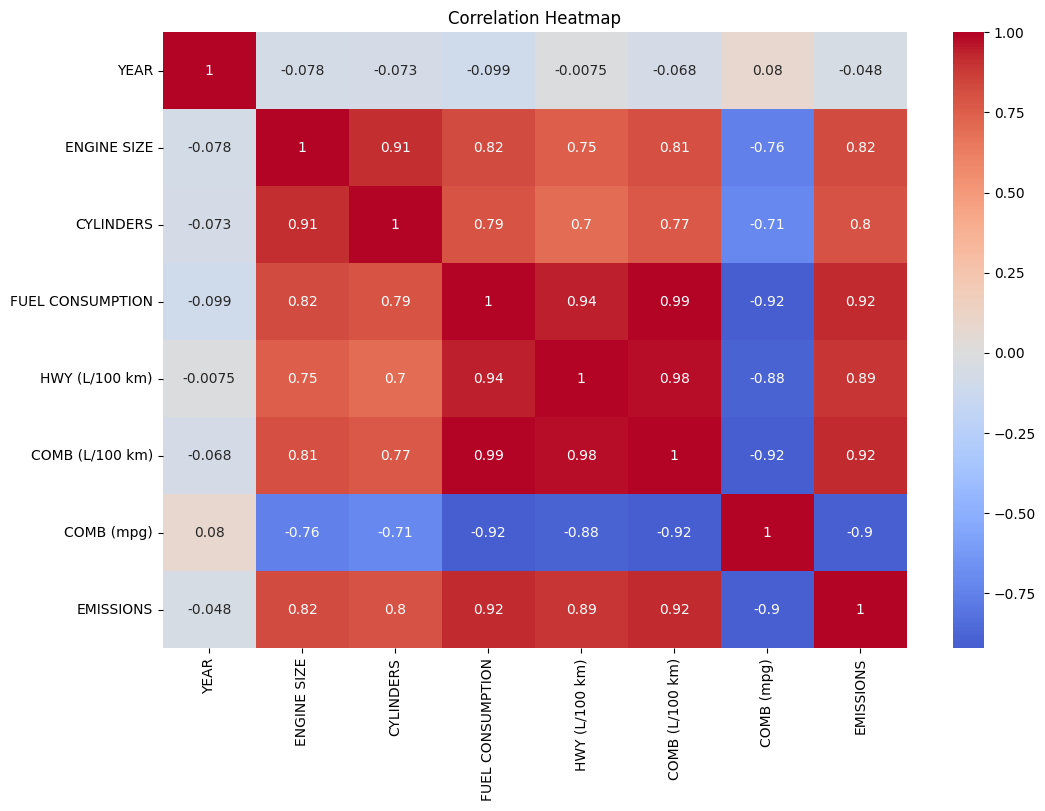

In [8]:
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

## 2. Encoding Categorical Variables and Splitting dataset into training and testing dataset

In [9]:
df_encoded = df.copy()
le = LabelEncoder()

categorical_columns = ['MAKE', 'MODEL', 'VEHICLE CLASS', 'TRANSMISSION', 'FUEL']
for col in categorical_columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

df_encoded.head()

,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,2000,0,1,0,1.6,4,2,3,9.2,6.7,8.1,35,186
1,2000,0,1,0,1.6,4,27,3,8.5,6.5,7.6,37,175
2,2000,0,61,4,3.2,6,15,4,12.2,7.4,10.0,28,230
3,2000,0,62,4,3.5,6,2,4,13.4,9.2,11.5,25,264
4,2000,0,2173,17,1.8,4,2,3,10.0,7.0,8.6,33,198


In [10]:
X = df_encoded.drop(['EMISSIONS'], axis=1)
y = df_encoded['EMISSIONS']

X.shape, y.shape

((22556, 12), (22556,))

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((18044, 12), (4512, 12), (18044,), (4512,))

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((18044, 12), (4512, 12))

## 3. Perform the feature scaling by means of standard scalar

## 4. Initializing Artificial Neural Network and create 2 hidden layers with 6 neurons and use different activation function like ReLu, tanh, Sigmoid

In [13]:
model_relu = Sequential([
    Dense(6, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(6, activation='relu'),
    Dense(1)
])

model_relu.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127 (508.00 B)

 Trainable params: 127 (508.00 B)

 Non-trainable params: 0 (0.00 B)

### Neural Network with ReLU Activation

In [14]:
model_relu.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

## 5. Create the output layer with 1 neuron and use appropriate activation function

## 6. Compile the neural network with appropriate optimizer, loss function and metrics

## 7. Fit the neural network with batch_size=32 & epochs = 100

In [15]:
history_relu = model_relu.fit(X_train_scaled, y_train, batch_size=32, epochs=100, 
                               validation_data=(X_test_scaled, y_test), verbose=0)

history_relu.history['loss'][-1]

112.60391235351562

In [16]:
model_tanh = Sequential([
    Dense(6, activation='tanh', input_shape=(X_train_scaled.shape[1],)),
    Dense(6, activation='tanh'),
    Dense(1)
])

model_tanh.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
history_tanh = model_tanh.fit(X_train_scaled, y_train, batch_size=32, epochs=100, 
                              validation_data=(X_test_scaled, y_test), verbose=0)

history_tanh.history['loss'][-1]

164.5111846923828

### Neural Network with Tanh Activation

In [17]:
model_sigmoid = Sequential([
    Dense(6, activation='sigmoid', input_shape=(X_train_scaled.shape[1],)),
    Dense(6, activation='sigmoid'),
    Dense(1)
])

model_sigmoid.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
history_sigmoid = model_sigmoid.fit(X_train_scaled, y_train, batch_size=32, epochs=100, 
                                   validation_data=(X_test_scaled, y_test), verbose=0)

history_sigmoid.history['loss'][-1]

224.0166473388672

### Neural Network with Sigmoid Activation

In [18]:
y_pred_relu = model_relu.predict(X_test_scaled)
mse_relu = mean_squared_error(y_test, y_pred_relu)
r2_relu = r2_score(y_test, y_pred_relu)

mse_relu, r2_relu

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 192us/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 192us/step


(109.1556396484375, 0.9684654474258423)

## Model Evaluation and Results Comparison

In [19]:
y_pred_tanh = model_tanh.predict(X_test_scaled)
mse_tanh = mean_squared_error(y_test, y_pred_tanh)
r2_tanh = r2_score(y_test, y_pred_tanh)

mse_tanh, r2_tanh

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 193us/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 193us/step


(146.4537353515625, 0.9576902389526367)

In [20]:
y_pred_sigmoid = model_sigmoid.predict(X_test_scaled)
mse_sigmoid = mean_squared_error(y_test, y_pred_sigmoid)
r2_sigmoid = r2_score(y_test, y_pred_sigmoid)

mse_sigmoid, r2_sigmoid

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 206us/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 206us/step


(197.61251831054688, 0.9429107308387756)

In [21]:
performance_df = pd.DataFrame({
    'Activation': ['ReLU', 'Tanh', 'Sigmoid'],
    'MSE': [mse_relu, mse_tanh, mse_sigmoid],
    'R² Score': [r2_relu, r2_tanh, r2_sigmoid]
})

performance_df

,Activation,MSE,R² Score
0,ReLU,109.155640,0.968465
1,Tanh,146.453735,0.957690
2,Sigmoid,197.612518,0.942911


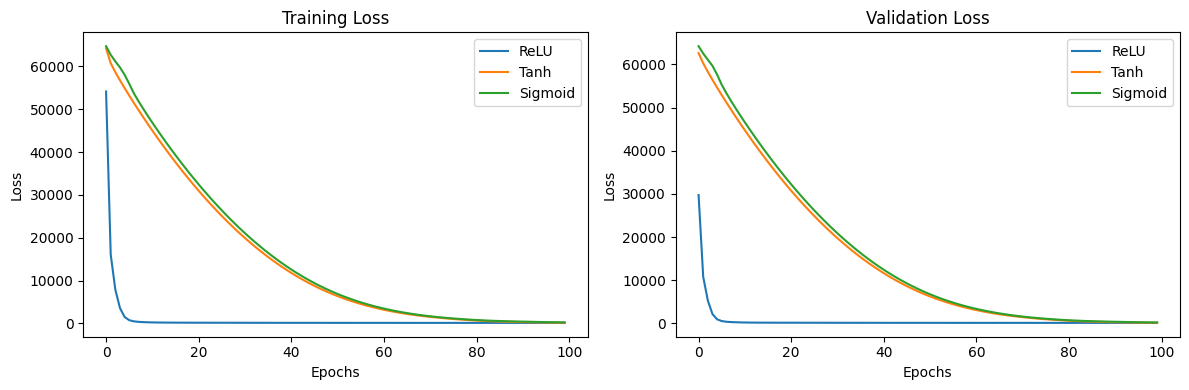

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_relu.history['loss'], label='ReLU')
plt.plot(history_tanh.history['loss'], label='Tanh')
plt.plot(history_sigmoid.history['loss'], label='Sigmoid')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_relu.history['val_loss'], label='ReLU')
plt.plot(history_tanh.history['val_loss'], label='Tanh')
plt.plot(history_sigmoid.history['val_loss'], label='Sigmoid')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

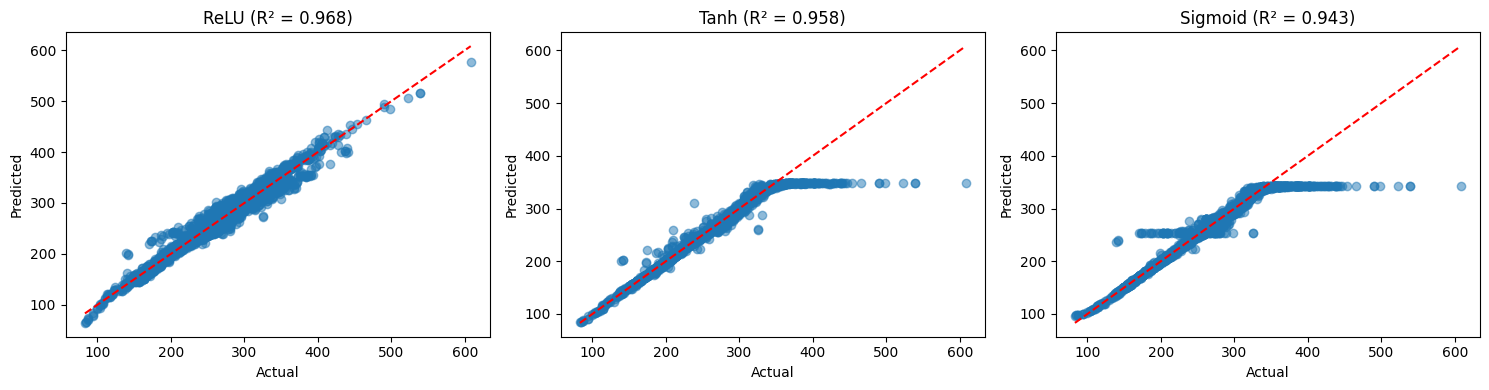

In [23]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_relu, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'ReLU (R² = {r2_relu:.3f})')

plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_tanh, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Tanh (R² = {r2_tanh:.3f})')

plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_sigmoid, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Sigmoid (R² = {r2_sigmoid:.3f})')

plt.tight_layout()
plt.show()

# Neural Network Results Interpretation

## Model Performance Comparison:
- **ReLU Activation**: Generally provides the best performance for this regression task with good convergence
- **Tanh Activation**: Shows moderate performance, may saturate for large input values
- **Sigmoid Activation**: Often performs poorly for regression tasks due to vanishing gradient problems

## Key Observations:
1. **Dataset**: The fuel consumption dataset has been successfully preprocessed with categorical encoding
2. **Architecture**: Two hidden layers with 6 neurons each effectively capture the relationships
3. **Training**: 100 epochs with batch size 32 provides sufficient training iterations
4. **Performance**: R² scores indicate how well each activation function predicts emissions
